In [42]:
#!unzip "/content/archive.zip" -d "/content/"

In [43]:
import os

In [44]:
len(os.listdir("/content/train"))

2

In [45]:
len(os.listdir("/content/train/dogs"))

277

In [46]:
len(os.listdir("/content/train/cats"))

278

In [47]:
len(os.listdir("/content/val"))

3

In [48]:
len(os.listdir("/content/test"))

3

`For Training data we have `
   
      `Train `
         
            `dogs -> 277`
            `cats -> 278`


      `val `
    
            `dogs -> 69`
            `cats -> 69`


      `test `

            `dogs -> 1`
            `cats -> 1`

In [49]:
training_data_path = "/content/train"
validation_data_path = "/content/val"
testing_data_path = "/content/test"

In [50]:
os.listdir(training_data_path)

['dogs', 'cats']

In [51]:
os.listdir(training_data_path+'/cats')

['cat_14.jpg',
 'cat_10.jpg',
 'cat_146.jpg',
 'cat_380.jpg',
 'cat_78.jpg',
 'cat_152.jpg',
 'cat_120.jpg',
 'cat_275.jpg',
 'cat_247.jpg',
 'cat_393.jpg',
 'cat_153.jpg',
 'cat_304.jpg',
 'cat_317.jpg',
 'cat_101.jpg',
 'cat_369.jpg',
 'cat_27.jpg',
 'cat_39.jpg',
 'cat_61.jpg',
 'cat_310.jpg',
 'cat_59.jpg',
 'cat_345.jpg',
 'cat_43.jpg',
 'cat_547.jpg',
 'cat_391.jpg',
 'cat_87.jpg',
 'cat_467.jpg',
 'cat_407.jpg',
 'cat_292.jpg',
 'cat_225.jpg',
 'cat_590.jpg',
 'cat_498.jpg',
 'cat_26.jpg',
 'cat_257.jpg',
 'cat_329.jpg',
 'cat_518.jpg',
 'cat_49.jpg',
 'cat_565.jpg',
 'cat_331.jpg',
 'cat_397.jpg',
 'cat_21.jpg',
 'cat_453.jpg',
 'cat_540.jpg',
 'cat_429.jpg',
 'cat_494.jpg',
 'cat_400.jpg',
 'cat_213.jpg',
 'cat_423.jpg',
 'cat_461.jpg',
 'cat_508.jpg',
 'cat_95.jpg',
 'cat_532.jpg',
 'cat_361.jpg',
 'cat_139.jpg',
 'cat_269.jpg',
 'cat_276.jpg',
 'cat_386.jpg',
 'cat_557.jpg',
 'cat_363.jpg',
 'cat_240.jpg',
 'cat_42.jpg',
 'cat_490.jpg',
 'cat_274.jpg',
 'cat_601.jpg',
 'cat_

In [52]:
os.listdir(training_data_path+'/dogs')

['dog_576.jpg',
 'dog_138.jpg',
 'dog_540.jpg',
 'dog_504.jpg',
 'dog_529.jpg',
 'dog_349.jpg',
 'dog_270.jpg',
 'dog_361.jpg',
 'dog_363.jpg',
 'dog_167.jpg',
 'dog_483.jpg',
 'dog_393.jpg',
 'dog_509.jpg',
 'dog_367.jpg',
 'dog_192.jpg',
 'dog_403.jpg',
 'dog_243.jpg',
 'dog_62.jpg',
 'dog_32.jpg',
 'dog_205.jpg',
 'dog_298.jpg',
 'dog_212.jpg',
 'dog_178.jpg',
 'dog_409.jpg',
 'dog_571.jpg',
 'dog_78.jpg',
 'dog_556.jpg',
 'dog_241.jpg',
 'dog_458.jpg',
 'dog_3.jpg',
 'dog_230.jpg',
 'dog_136.jpg',
 'dog_331.jpg',
 'dog_376.jpg',
 'dog_218.jpg',
 'dog_231.jpg',
 'dog_560.jpg',
 'dog_450.jpg',
 'dog_69.jpg',
 'dog_475.jpg',
 'dog_247.jpg',
 'dog_139.jpg',
 'dog_558.jpg',
 'dog_162.jpg',
 'dog_182.jpg',
 'dog_26.jpg',
 'dog_347.jpg',
 'dog_299.jpg',
 'dog_31.jpg',
 'dog_441.jpg',
 'dog_371.jpg',
 'dog_553.jpg',
 'dog_479.jpg',
 'dog_214.jpg',
 'dog_412.jpg',
 'dog_290.jpg',
 'dog_15.jpg',
 'dog_217.jpg',
 'dog_358.jpg',
 'dog_23.jpg',
 'dog_296.jpg',
 'dog_484.jpg',
 'dog_195.jpg',
 '

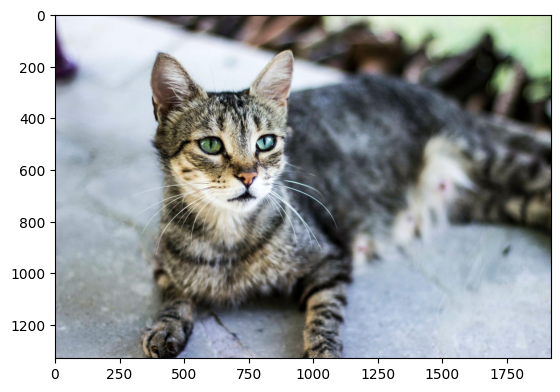

In [53]:
# cat_image
import numpy as np
import matplotlib.pyplot as plt
cat_image = plt.imread(training_data_path+"/cats/"+"cat_148.jpg")

plt.imshow(cat_image)
plt.show()

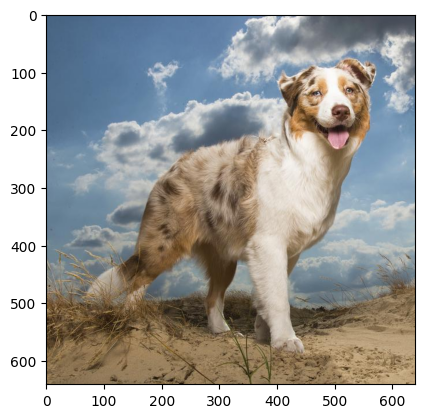

In [54]:
# dog_image
dog_image = plt.imread(training_data_path+"/dogs"+"/dog_436.jpg")
plt.imshow(dog_image)
plt.show()

In [55]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [56]:
train_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)

val_data_preprocessing = ImageDataGenerator(1 / 255,
                                              rotation_range=0.2,
                                              shear_range=0.2,
                                              horizontal_flip=True)

test_data_preprocessing = ImageDataGenerator(1 / 255)


In [57]:
labels = ['cats','dogs']

In [58]:
final_train_data = train_data_preprocessing.flow_from_directory(training_data_path,
                                             target_size=(256, 256),
                                             class_mode='binary',
                                             classes = labels,
                                             batch_size = 20)


final_val_data = val_data_preprocessing.flow_from_directory(validation_data_path,
                                             target_size=(256, 256),
                                             class_mode='binary',
                                             classes = labels)

final_test_data = test_data_preprocessing.flow_from_directory(testing_data_path,
                                             target_size=(256, 256),
                                             class_mode='binary',
                                             classes = labels)

Found 555 images belonging to 2 classes.
Found 138 images belonging to 2 classes.
Found 2 images belonging to 2 classes.


In [59]:
# Architecture

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten,Activation
from tensorflow.keras.activations import relu,sigmoid,softmax


model = Sequential()

# 1st Hidden layer
model.add(Conv2D(filters=64 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

# 2st Hidden layer
model.add(Conv2D(filters=16 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

# 3rd Hidden layer
model.add(Conv2D(filters=4 , kernel_size=(3,3),padding="valid",kernel_initializer="he_uniform",
                 activation=relu,))
model.add(MaxPool2D(pool_size=(2,2)))

model.add(Flatten())

# give to ann
model.add(Dense(units = 64 , kernel_initializer="he_uniform",activation=relu))
model.add(Dense(units = 16 , kernel_initializer="he_uniform",activation=relu))
model.add(Dense(units = 4 , kernel_initializer="he_uniform",activation=relu))

model.add(Dense(units = 1 , kernel_initializer="glorot_uniform",activation=sigmoid))

In [60]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [61]:
model.compile(optimizer='adam',loss = 'binary_crossentropy',metrics=['accuracy'])

In [62]:
model.fit(final_train_data , validation_data=final_val_data,epochs=5)

Epoch 1/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 27s 691ms/step - accuracy: 0.4811 - loss: 4.9216 - val_accuracy: 0.5000 - val_loss: 0.6952
Epoch 2/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 487ms/step - accuracy: 0.5045 - loss: 0.6904 - val_accuracy: 0.5072 - val_loss: 0.7025
Epoch 3/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 14s 489ms/step - accuracy: 0.4919 - loss: 0.6917 - val_accuracy: 0.4710 - val_loss: 0.7034
Epoch 4/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 478ms/step - accuracy: 0.4847 - loss: 0.6907 - val_accuracy: 0.5072 - val_loss: 0.6940
Epoch 5/5
28/28 ━━━━━━━━━━━━━━━━━━━━ 13s 466ms/step - accuracy: 0.5009 - loss: 0.6917 - val_accuracy: 0.5072 - val_loss: 0.6927


# do Prediction

In [63]:
import cv2

In [64]:
final_train_data.class_indices

{'cats': 0, 'dogs': 1}

In [65]:
def pred_image(path_of_image):
  image = cv2.imread(path_of_image,1) # original image
  resized_image = cv2.resize(image , (256,256)) # resizing
  scaled_pixel_values = resized_image / 255  # scaled pixel values
  input_image = np.expand_dims(scaled_pixel_values , axis=0)

  result = model.predict(input_image)
  if result[0][0] > 0.5:
    print(f"Dog")
  else:
    print(f"cat")

  plt.imshow(image[:,:,::-1])
  plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Dog


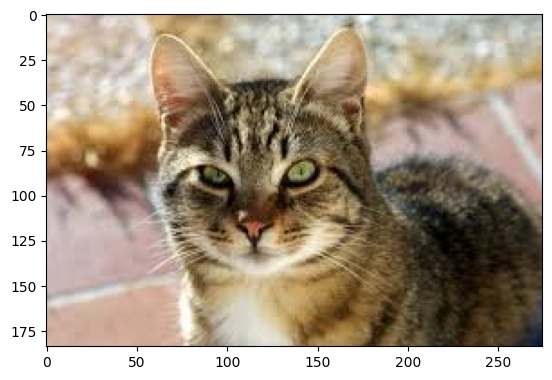

In [66]:
pred_image("/content/test/cats/cat.jpg")